In [1]:
import scanpy as sc
import numpy as np
import torch
import umap
import igraph as ig
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from BFM.MCMC_LH import Gibbs_sampling

/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device1 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.set_figure_params(dpi = 80, facecolor = "white")
sc.logging.print_header()

/var/folders/f1/vfn7kw6j4p3782v8nkrsr0hc0000gn/T/ipykernel_13887/1079186296.py:3: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
scanpy,1.11.4
numpy,2.2.5
torch,2.10.0
umap-learn,0.5.9.post2
igraph,0.11.5
matplotlib,3.10.0
scikit-learn,1.6.1
Component,Info
Python,"3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]"
OS,macOS-26.3.1-arm64-arm-64bit


In [4]:
# Read in the count matrix into an {class}`~anndata.AnnData` object, which holds many slots for annotations and different representations of the data. 
adata = sc.read_10x_mtx(
    "data/filtered_gene_bc_matrices/hg19/",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    cache = True,  # write a cache file for faster subsequent reading
)

adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`

... reading from cache file cache/data-filtered_gene_bc_matrices-hg19-matrix.h5ad


normalizing counts per cell
    finished (0:00:00)


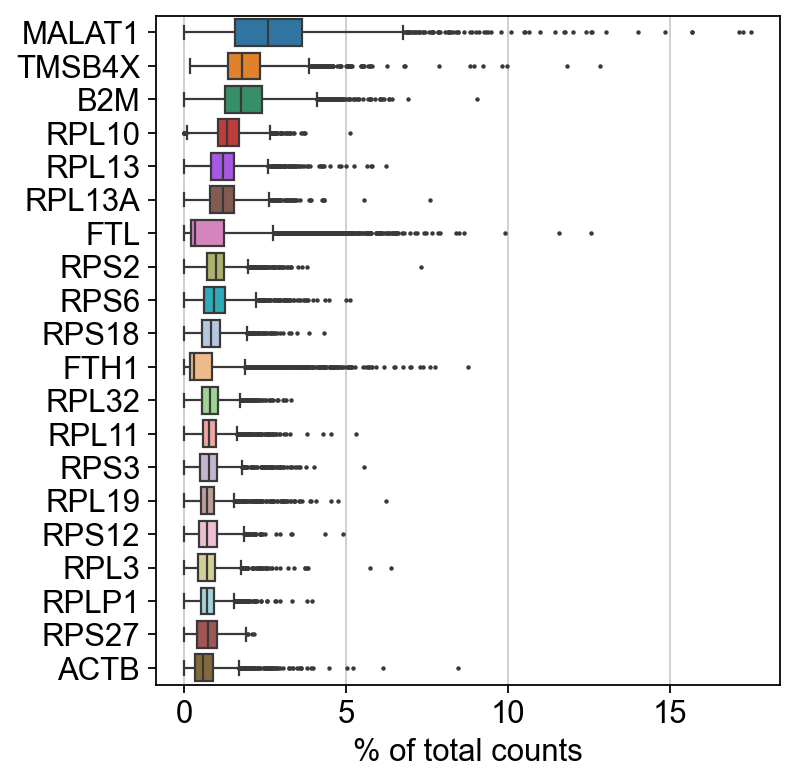

In [5]:
# Show those genes that yield the highest fraction of counts in each single cell, across all cells.
sc.pl.highest_expr_genes(adata, n_top = 20)

In [6]:
# Basic filtering:
sc.pp.filter_cells(adata, min_genes = 200)  # this does nothing, in this specific case
sc.pp.filter_genes(adata, min_cells = 3)

filtered out 19024 genes that are detected in less than 3 cells


In [7]:
# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top = None, log1p = False, inplace = True
)

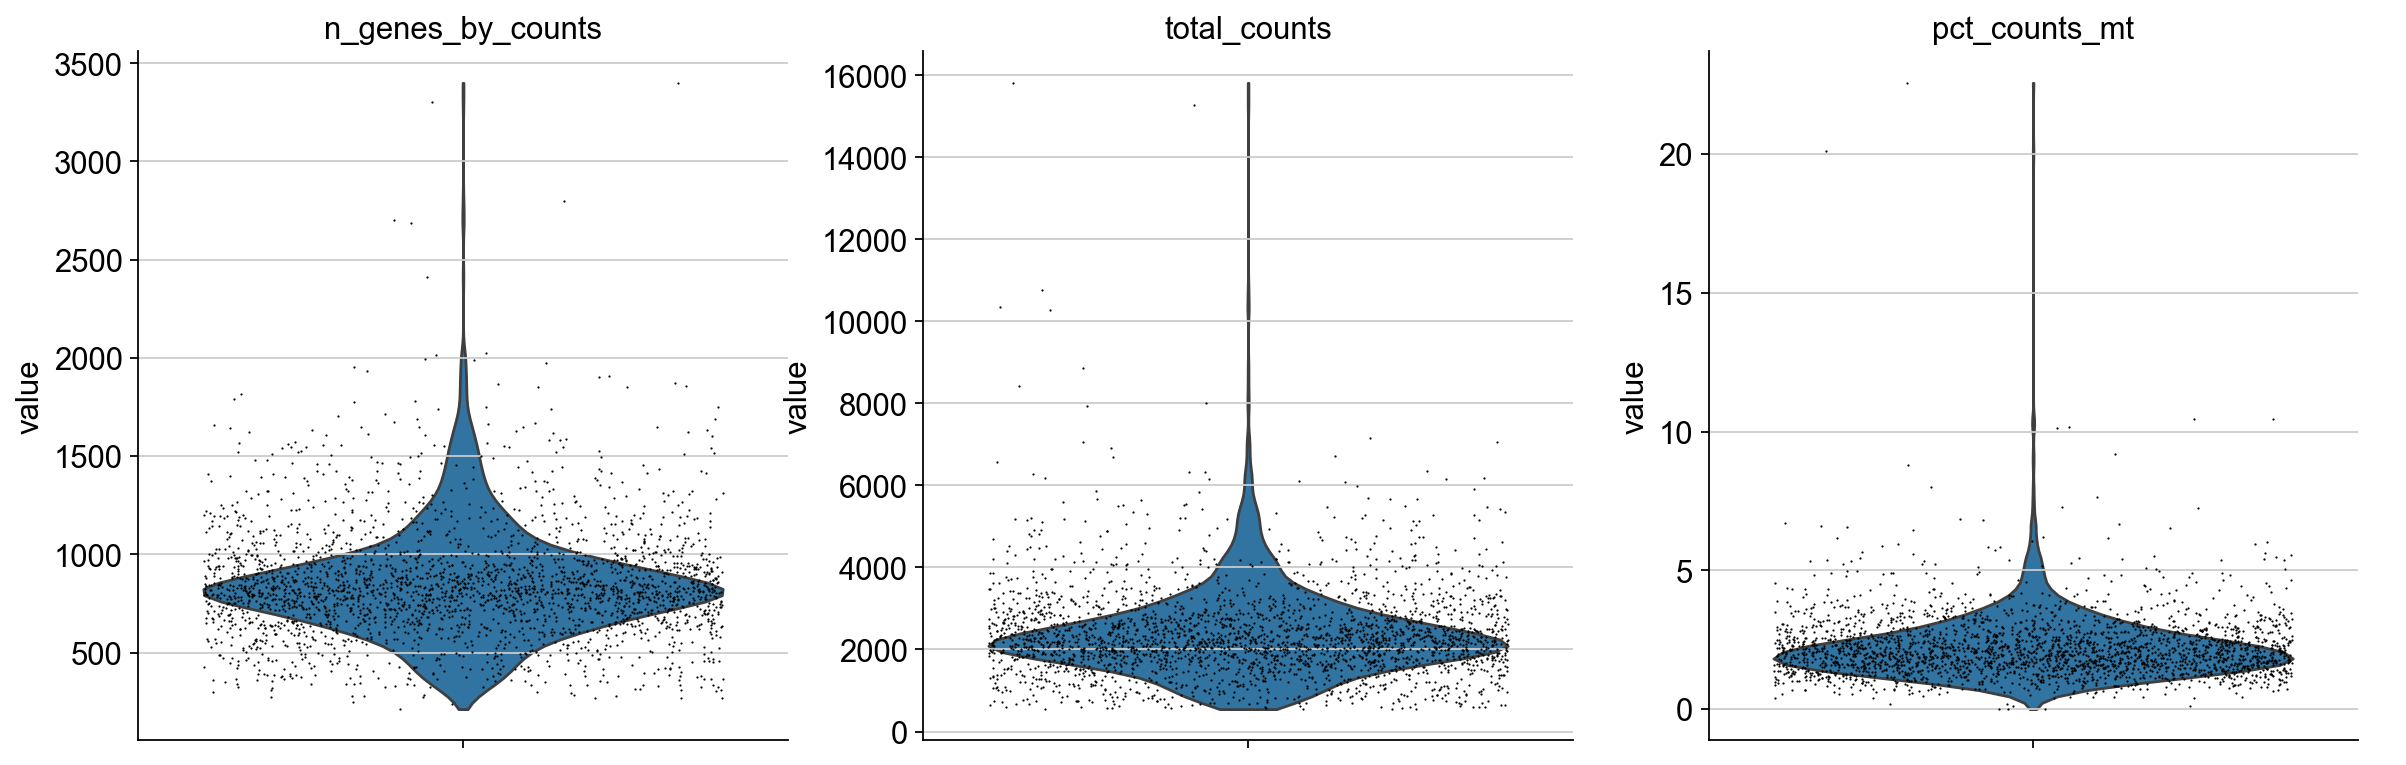

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter= 0.4,
    multi_panel=True,
)

<Axes: xlabel='total_counts', ylabel='n_genes_by_counts'>

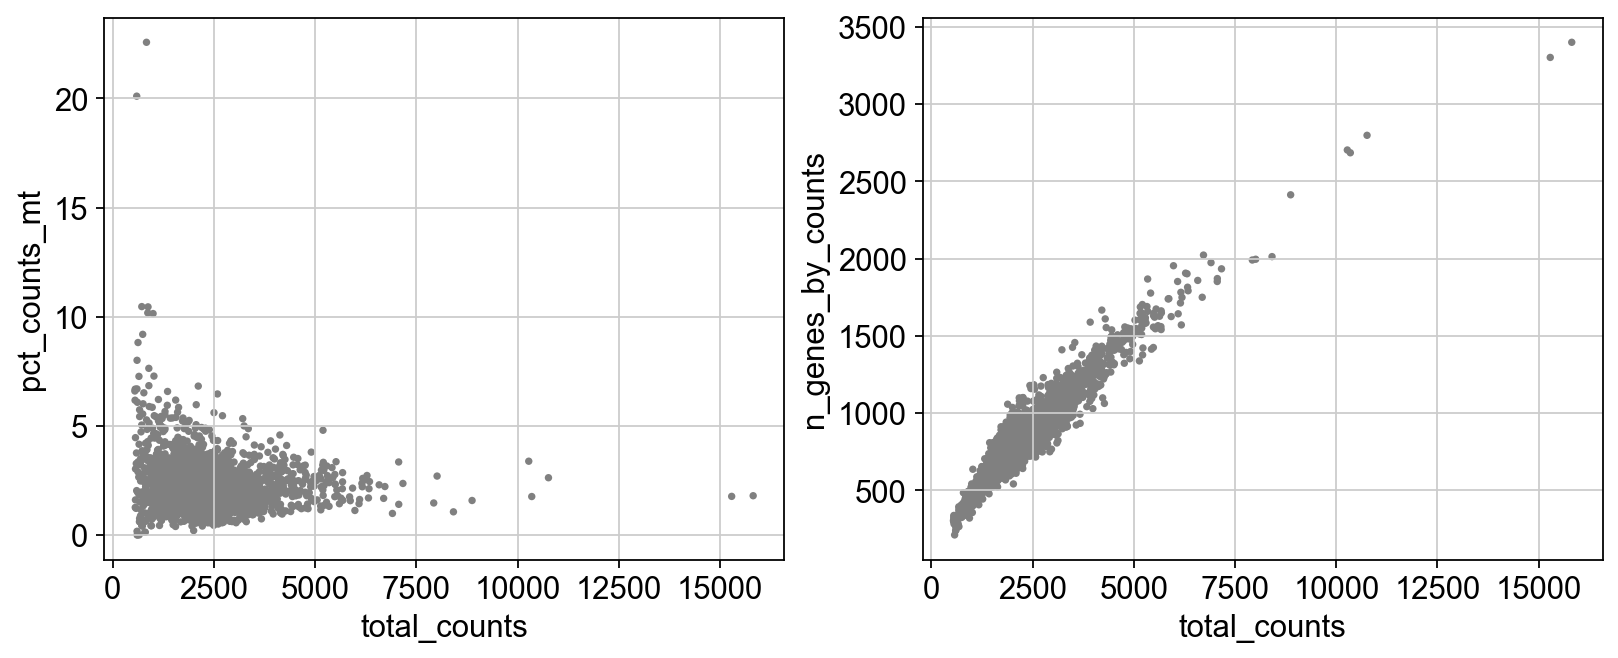

In [9]:
# Remove cells that have too many mitochondrial genes expressed or too many total counts:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show = False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show = False, ax=axs[1])

In [10]:
adata = adata[
    (adata.obs.n_genes_by_counts < 2500)
    & (adata.obs.n_genes_by_counts > 200)
    & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
adata.layers["counts"] = adata.X.copy()

In [11]:
# Total-count normalize (library-size correct) the data matrix X to 10,000 reads per cell, so that counts become comparable among cells.
sc.pp.normalize_total(adata, target_sum= 1e4)

# Logarithmize the data:
sc.pp.log1p(adata)


normalizing counts per cell
    finished (0:00:00)


extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


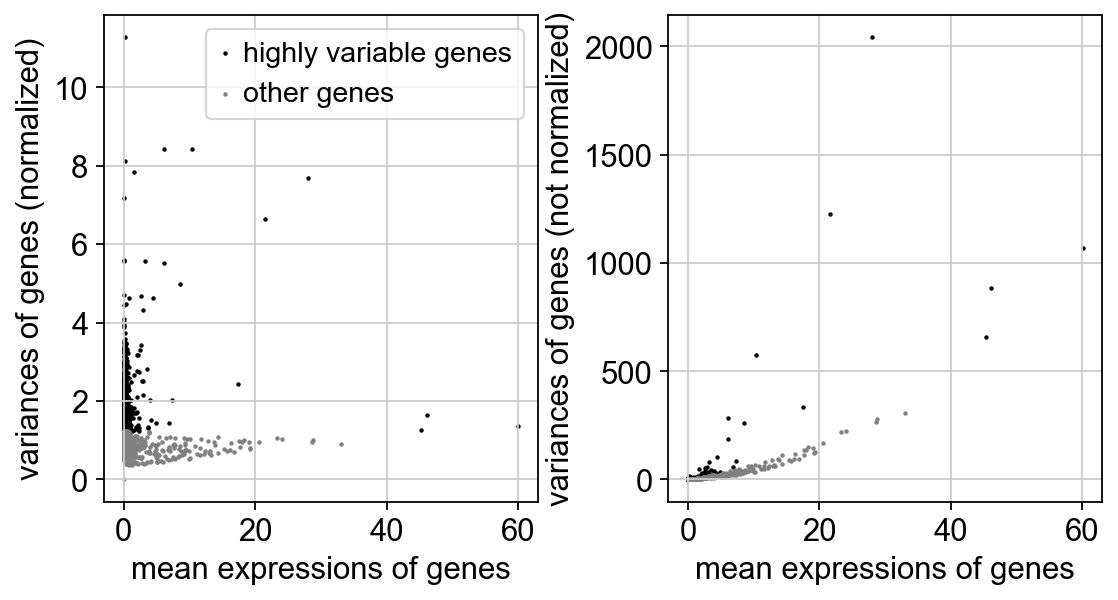

In [12]:
# Identify highly-variable genes. 
sc.pp.highly_variable_genes(
    adata,
    layer="counts",
    n_top_genes = 2000,
    min_mean= 0.0125,
    max_mean= 3,
    min_disp= 0.5,
    flavor="seurat_v3",
)

sc.pl.highly_variable_genes(adata)

In [13]:
# Scale each gene to unit variance. Clip values exceeding standard deviation 10.
adata1 = adata[:,adata.var.highly_variable].copy()
adata1.layers["scaled"] = adata1.X.toarray()
sc.pp.regress_out(adata1, ["total_counts", "pct_counts_mt"], layer="scaled")
sc.pp.scale(adata1, max_value = 10, layer="scaled")

regressing out ['total_counts', 'pct_counts_mt']
    finished (0:00:00)


In [14]:
X = adata1.layers['scaled']

In [15]:
B_sample, eta_sample, sigma2_sample = Gibbs_sampling(X, device = device1, score = True)

100%|██████████| 9999/9999 [2:02:39<00:00,  1.36it/s]  


In [16]:
B_mean = torch.mean(B_sample, axis = 0)
eta_mean = torch.mean(eta_sample, axis = 0)
norm_B = torch.norm(B_mean, dim = 0)

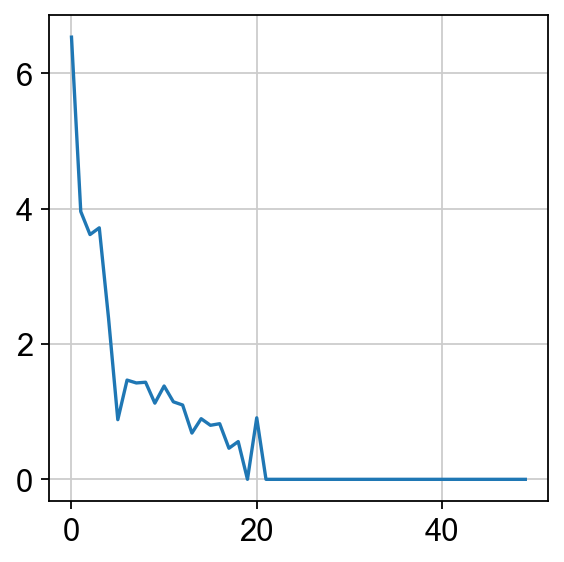

In [17]:
plt.plot(norm_B.cpu().numpy())
plt.show()

In [19]:
score = eta_mean[0:21,:].T * norm_B[0:21]

In [26]:
k =  45
nbrs = NearestNeighbors(n_neighbors = k).fit(score)
distances, indices = nbrs.kneighbors(score)

In [27]:
cell_g = ig.Graph(directed = False)
cell_g.add_vertices(len(score))  # Add cells as nodes

# Add edges between neighbors
edges = [(i, j) for i in range(len(indices)) for j in indices[i]]
cell_g.add_edges(edges)

In [28]:
clusters = cell_g.community_leiden(
    objective_function= "modularity",  # or "CPM"
    resolution_parameter= 1.0  # Adjust for cluster granularity
)
labels = clusters.membership

/var/folders/f1/vfn7kw6j4p3782v8nkrsr0hc0000gn/T/ipykernel_13887/1326081083.py:1: DeprecationWarning: resolution_parameter keyword argument is deprecated, use resolution=... instead
  clusters = cell_g.community_leiden(


In [29]:
reducer = umap.UMAP(
    n_neighbors = 45,          # Match k-NN graph parameter
    min_dist= 0.3,            # Balance between local/global (0.1-0.5)
    n_components = 2,          # 2D for visualization
)
umap_embedding = reducer.fit_transform(score)

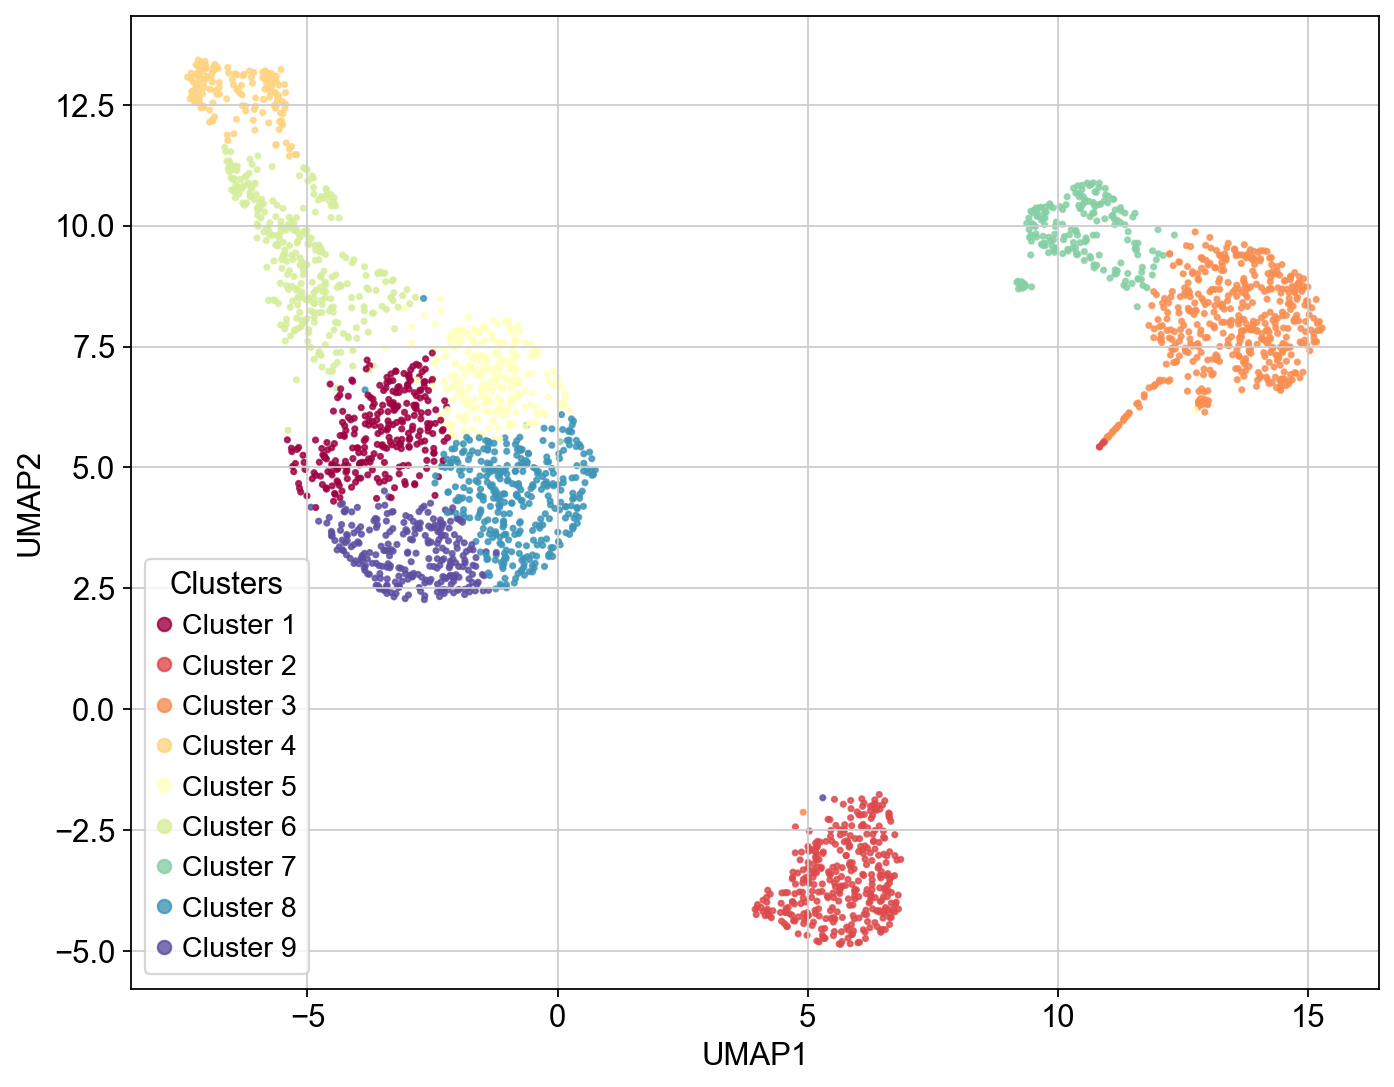

In [30]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1],
    c = labels,                # Cluster labels from igraph
    cmap = "Spectral",         # Use "tab20" for discrete clusters
    s = 5,                     # Point size
    alpha = 0.8                # Transparency
)

# Modified legend to start from 1
# We calculate the number of clusters and create a range from 1 to N+1
num_clusters = max(labels) + 1
cluster_ids = range(1, num_clusters + 1)

plt.legend(
    handles= scatter.legend_elements()[0], 
    labels=[f"Cluster {i}" for i in cluster_ids], # Changed to start from 1
    title= "Clusters",
    loc="best"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

In [31]:
# Add cluster labels to adata object
adata.obs['leiden'] = [str(label) for label in labels]

# Now identify marker genes for each cluster
print("Finding marker genes for each cluster...")
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

Finding marker genes for each cluster...
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [32]:
# Get the results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

In [33]:
# Print top 3 marker genes for each cluster
print("\nTop 3 marker genes for each cluster:")
marker_dict = {}
for group in groups:
    top_genes = [result['names'][group][i] for i in range(3)]
    marker_dict[group] = top_genes
    print(f"Cluster {group}: {top_genes}")


Top 3 marker genes for each cluster:
Cluster 0: ['LTB', 'IL7R', 'LDHB']
Cluster 1: ['CD74', 'HLA-DRA', 'CD79A']
Cluster 2: ['LYZ', 'S100A9', 'S100A8']
Cluster 3: ['GZMB', 'NKG7', 'GNLY']
Cluster 4: ['IL32', 'LTB', 'CD3D']
Cluster 5: ['CCL5', 'NKG7', 'CST7']
Cluster 6: ['COTL1', 'LST1', 'FCER1G']
Cluster 7: ['RPS27', 'RPL32', 'RPS12']
Cluster 8: ['RPS6', 'RPS3A', 'RPS12']
